In [1]:
!pip install kaggle


In [3]:
import os

os.makedirs("/root/.config/kaggle", exist_ok=True)
!cp kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json


In [4]:
!kaggle kernels pull fareselmenshawii/cats-vs-dogs-classification


Source code downloaded to /content/cats-vs-dogs-classification.ipynb


In [5]:
!kaggle datasets download -d tongpython/cat-and-dog


Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 72% 156M/218M [00:00<00:00, 1.63GB/s]
100% 218M/218M [00:00<00:00, 853MB/s] 


In [6]:
!unzip cat-and-dog.zip


Streaming output truncated to the last 5000 lines.
  inflating: training_set/training_set/cats/cat.3704.jpg  
  inflating: training_set/training_set/cats/cat.3705.jpg  
  inflating: training_set/training_set/cats/cat.3706.jpg  
  inflating: training_set/training_set/cats/cat.3707.jpg  
  inflating: training_set/training_set/cats/cat.3708.jpg  
  inflating: training_set/training_set/cats/cat.3709.jpg  
  inflating: training_set/training_set/cats/cat.371.jpg  
  inflating: training_set/training_set/cats/cat.3710.jpg  
  inflating: training_set/training_set/cats/cat.3711.jpg  
  inflating: training_set/training_set/cats/cat.3712.jpg  
  inflating: training_set/training_set/cats/cat.3713.jpg  
  inflating: training_set/training_set/cats/cat.3714.jpg  
  inflating: training_set/training_set/cats/cat.3715.jpg  
  inflating: training_set/training_set/cats/cat.3716.jpg  
  inflating: training_set/training_set/cats/cat.3717.jpg  
  inflating: training_set/training_set/cats/cat.3718.jpg  
  infl

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout


In [15]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    directory="/content/training_set/training_set",
    labels="inferred",
    label_mode="int",   # cats vs dogs
    image_size=(256, 256),
    batch_size=32,)


validation_ds = image_dataset_from_directory(
    directory="/content/test_set/test_set",
    labels="inferred",
    label_mode="int",   # cats vs dogs
    image_size=(256, 256),
    batch_size=32,)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [16]:
# Normalize images to [0, 1]
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [17]:
#create cnn model
model=Sequential()
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='valid',
        activation='relu',
        input_shape=(256, 256, 3)   # very important
    )
)
model.add(BatchNormalization())
model.add(
    MaxPooling2D(
        pool_size=(2,2),
        strides=2,
        padding='valid'
        )
    )
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding='valid',
        activation='relu',
        input_shape=(256, 256, 3)   # very important
    )
)
model.add(BatchNormalization())
model.add(
    MaxPooling2D(
        pool_size=(2,2),
        strides=2,
        padding='valid'
        )
    )
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding='valid',
        activation='relu',
        input_shape=(256, 256, 3)   # very important
    )
)
model.add(BatchNormalization())
model.add(
    MaxPooling2D(
        pool_size=(2,2),
        strides=2,
        padding='valid'
        )
    )

model.add(Flatten())
model.add(Dense(128,activation='relu'));
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'));
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'));



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.9415 - loss: 0.1551 - val_accuracy: 0.7622 - val_loss: 0.7520
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9530 - loss: 0.1286 - val_accuracy: 0.7365 - val_loss: 0.9340
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step - accuracy: 0.9666 - loss: 0.0933 - val_accuracy: 0.7598 - val_loss: 0.8633
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.9684 - loss: 0.0893 - val_accuracy: 0.6831 - val_loss: 2.0707
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.9707 - loss: 0.0725 - val_accuracy: 0.7479 - val_loss: 0.9413
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9784 - loss: 0.0613 - val_accuracy: 0.7425 - val_loss: 0.9184
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.9758 - loss: 0.0691 - val_accuracy: 0.7603 - val_loss: 1.0458
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.9761 - loss: 0.0704

 ways to reduce overfitting
 1 Add more data
 2 Data augmentation
 3 L1/L2 Regularization
 4 Dropout
 5 Batch Norm
 6 Reduce Complexity

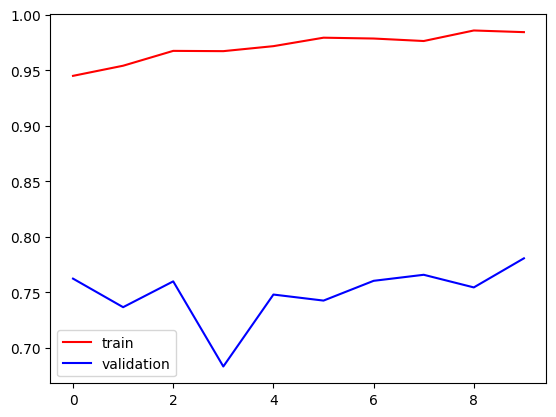

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

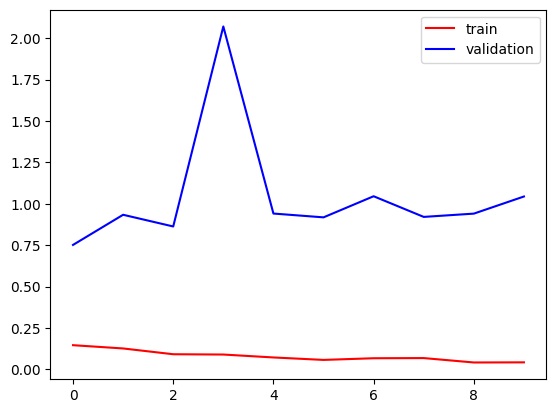

In [23]:

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [24]:
import cv2

In [33]:
test_image=cv2.imread('/content/dog.jpg')

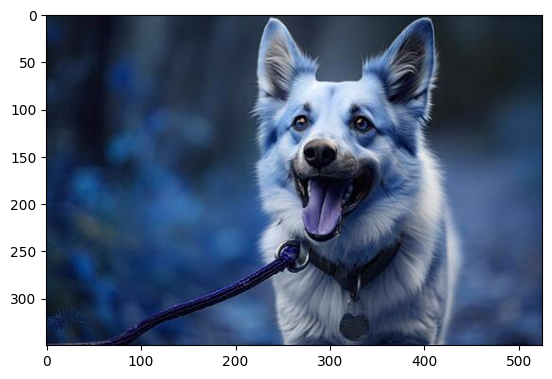

In [34]:
plt.imshow(test_image)

In [35]:
test_image.shape

(350, 525, 3)

In [36]:
test_img=cv2.resize(test_image,(256,256))

In [37]:
test_input=test_img.reshape((1,256,256,3))

In [39]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.]], dtype=float32)